# Laboratorio 4
### Predicción de cancelación de reservas de hotel
repositorio git hub
https://github.com/jccondoric/machine_learning/tree/master/Laboratorios/Laboratorio_4 <br>
**Dataset:** Hotel Booking Demand
**Fuente:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
**Cantidad de ejemplos:** 119,390 reservas
**Cantidad de propiedades originales:** 31 (más la variable objetivo)
**Variable objetivo:** `is_canceled` (1 = la reserva fue cancelada, 0 = no fue cancelada)

El objetivo de este laboratorio es entrenar un modelo de regresión logística binaria, implementado desde cero (sin usar `sklearn.linear_model`), que prediga si una reserva de hotel será cancelada a partir de las características de la reserva y del huésped. Se sigue el flujo: carga y limpieza del dataset con Pandas, separación en conjunto de entrenamiento (80%) y prueba (20%), entrenamiento por descenso de gradiente, visualización de la curva de costo, y validación del modelo con datos que nunca vio durante el entrenamiento.

In [18]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Manejo de rutas y directorios
import os

# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación y trazado de graficos
from matplotlib import pyplot as plt
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline

np.random.seed(42)
%matplotlib inline

## 1. Carga del dataset

Se cargo el dataset `hotel_bookings.csv` y se hace una primera inspección para ver su tamaño tipos de datos y valores nulos para tratar el dataset antes de entrenar el modelo

In [20]:
ruta = '/content/drive/MyDrive/IA/Laboratorios/Laboratorio_4/hotel_bookings.csv'

df = pd.read_csv(ruta)
print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [22]:
nulos = df.isnull().sum()
nulos[nulos > 0]

,0
children,4
country,488
agent,16340
company,112593


In [23]:
df['is_canceled'].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,62.958372
1,37.041628


## 2. Limpieza y selección de columnas

Se encontraron 3 problemas en la inspección anterior:
1. Columnas que "se copian" de la respuesta: las columnas reservation_status y reservation_status_date básicamente ya dicen si la reserva fue cancelada o no, solo que con otras palabras (dicen cosas como "Cancelada", "Check-Out" o "No se presentó"). Dejarlas sería como hacer trampa el modelo no aprendería nada solo copiaría la respuesta que ya está ahí. Por eso las elimino.
2. Columnas con demasiados datos faltantes: la columna company no tiene datos en más del 90% de las filas, y agent le falta información en un 14% de los casos. Como falta tanta información, no sirven de mucho para el modelo, así que también las eliminamos.
3. Una columna con demasiadas categorías distintas: la columna country tiene 177 países diferentes. Se intento convertirla en números (como hacemos con las demás columnas de texto), se genero 177 columnas nuevas, la mayoría con muy pocos datos cada una. Esto en vez de ayudar, metia ruido y confundia al modelo. Por eso la eliminamos también.

Después de quitar estas columnas, el dataset se queda con 26 propiedades de entrada, que sigue siendo más que suficiente (el mínimo pedido para el laboratorio era de 20).

In [24]:
columnas_a_eliminar = ['reservation_status', 'reservation_status_date', 'company', 'agent', 'country']
df = df.drop(columns=columnas_a_eliminar)
print('Dimensiones tras eliminar columnas:', df.shape)
print('Propiedades de entrada (sin contar is_canceled):', df.shape[1] - 1)

Dimensiones tras eliminar columnas: (119390, 27)
Propiedades de entrada (sin contar is_canceled): 26


### 2.1 Nulos restantes y valores atípicos

Solo queda una columna con nulos (`children`, con apenas 4 filas afectadas), que se completa con 0 porque lo más razonable es asumir que si no se registró el dato, no había niños en la reserva.

También se reviso `adr` (tarifa diaria promedio), que tiene un valor negativo (dato inválido) y un valor extremo de 5400, muy alejado del resto de la distribución. Se elimina la fila con valor negativo y se recorta el valor máximo a 1000 para evitar que ese outlier distorsione el entrenamiento.

In [25]:
df['children'] = df['children'].fillna(0)

df = df[df['adr'] >= 0]
df['adr'] = df['adr'].clip(upper=1000)

df.isnull().sum().sum()

np.int64(0)

## 3. Codificación de variables categóricas

El modelo de regresión logística solo trabaja con números, así que las columnas de texto (`hotel`, `arrival_date_month`, `meal`, `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`, `deposit_type`, `customer_type`) se transforman con **one-hot encoding** usando `pd.get_dummies`. Se usa `drop_first=True` para evitar generar una columna redundante por cada variable categórica (evitando colinealidad perfecta entre las columnas dummy).

In [26]:
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()
print('Columnas categóricas a codificar:', columnas_categoricas)

df_codificado = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)
print('Dimensiones finales tras codificación:', df_codificado.shape)

Columnas categóricas a codificar: ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Dimensiones finales tras codificación: (119389, 70)


## 4. Separación de variables y división 80/20

Se separa el dataset en la matriz de propiedades `X` y el vector objetivo `y`. Luego se divide manualmente en conjunto de entrenamiento (80%) y de prueba (20%): se mezclan los índices de cada clase por separado con `np.random.permutation` y se corta cada una en 80/20, para que ambos conjuntos mantengan la misma proporción de reservas canceladas/no canceladas que el dataset original (esto es lo que se conoce como una división estratificada). El conjunto de prueba queda completamente aislado: no se usa en ningún momento durante el entrenamiento ni para ajustar hiperparámetros.

In [27]:
X = df_codificado.drop(columns=['is_canceled']).values.astype(float)
y = df_codificado['is_canceled'].values.astype(float)

def split_estratificado(X, y, porcentaje_prueba=0.2, semilla=42):
    rng = np.random.default_rng(semilla)
    indices_train = []
    indices_test = []

    for clase in np.unique(y):
        indices_clase = np.where(y == clase)[0]
        indices_clase = rng.permutation(indices_clase)
        n_prueba = int(len(indices_clase) * porcentaje_prueba)
        indices_test.extend(indices_clase[:n_prueba])
        indices_train.extend(indices_clase[n_prueba:])

    indices_train = rng.permutation(indices_train)
    indices_test = rng.permutation(indices_test)
    return X[indices_train], X[indices_test], y[indices_train], y[indices_test]

X_train, X_test, y_train, y_test = split_estratificado(X, y, porcentaje_prueba=0.2, semilla=42)

print('Ejemplos de entrenamiento:', X_train.shape[0])
print('Ejemplos de prueba:', X_test.shape[0])
print('Propiedades finales:', X_train.shape[1])
print()
print('Proporcion de clase 1 en train:', y_train.mean().round(4))
print('Proporcion de clase 1 en test:', y_test.mean().round(4))

Ejemplos de entrenamiento: 95512
Ejemplos de prueba: 23877
Propiedades finales: 69

Proporcion de clase 1 en train: 0.3704
Proporcion de clase 1 en test: 0.3704


## 5. Escalado de propiedades

Las propiedades numéricas del dataset tienen escalas muy distintas (por ejemplo, `lead_time` puede llegar a más de 700, mientras que `adults` va de 0 a 4). Sin escalar, el descenso de gradiente avanza de forma desigual entre propiedades y converge mucho más lento. Se aplica estandarización manual (restar la media y dividir entre la desviación estándar), calculando la media y desviación **únicamente con los datos de entrenamiento**, y usando esos mismos valores para transformar tanto entrenamiento como prueba. Esto evita que información del conjunto de prueba se filtre al proceso de ajuste (lo cual también sería una forma de fuga de datos).

In [28]:
media_train = X_train.mean(axis=0)
desviacion_train = X_train.std(axis=0)
desviacion_train[desviacion_train == 0] = 1  # evita division por cero en columnas constantes

X_train_esc = (X_train - media_train) / desviacion_train
X_test_esc = (X_test - media_train) / desviacion_train

# Columna de unos para el termino de sesgo (intercepto) de theta_0
X_train_b = np.hstack([np.ones((X_train_esc.shape[0], 1)), X_train_esc])
X_test_b = np.hstack([np.ones((X_test_esc.shape[0], 1)), X_test_esc])

print('X_train_b:', X_train_b.shape)
print('X_test_b:', X_test_b.shape)

X_train_b: (95512, 70)
X_test_b: (23877, 70)


## 6. Función sigmoide

La regresión logística necesita convertir la combinación lineal de las propiedades (`z = X · theta`) en un valor interpretable como probabilidad, entre 0 y 1. Para eso se usa la función sigmoide. Se agrega un recorte (`clip`) del valor de `z` únicamente para evitar errores numéricos de desbordamiento (overflow) cuando `z` toma valores muy grandes o muy negativos; esto no cambia el resultado matemático de la sigmoide, solo evita que numpy genere advertencias o valores `inf`.

In [30]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

## 7. Función de costo y gradiente

Se implementa la función de costo de entropía cruzada, adecuada para clasificación binaria porque, a diferencia del error cuadrático medio, es una función convexa con respecto a `theta` cuando se combina con la sigmoide (tiene un único mínimo global, lo que garantiza que el descenso de gradiente no se quede atrapado en mínimos locales). Se agrega un término pequeño (`eps`) dentro de los logaritmos únicamente para evitar el error de calcular `log(0)` en casos extremos.

La misma función devuelve también el gradiente, que indica la dirección en la que hay que mover cada `theta_j` para reducir el costo.

In [32]:
def funcion_costo(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    eps = 1e-10
    J = (1 / m) * np.sum(-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps))
    gradiente = (1 / m) * (X.T.dot(h - y))
    return J, gradiente

## 8. Descenso de gradiente

Se implementa el descenso de gradiente de forma manual: en cada iteración se calcula el costo actual y el gradiente, y se actualiza `theta` dando un paso en la dirección que reduce el costo, con un tamaño de paso controlado por la tasa de aprendizaje `alpha`. Se guarda el historial de costo de cada iteración (`J_history`) para poder graficarlo después y verificar visualmente que el modelo efectivamente está aprendiendo (el costo debe bajar y estabilizarse, no oscilar ni crecer).

In [33]:
def descenso_gradiente(X, y, theta, alpha, num_iters):
    J_history = []
    for i in range(num_iters):
        J, gradiente = funcion_costo(theta, X, y)
        theta = theta - alpha * gradiente
        J_history.append(J)
    return theta, J_history

## 9. Entrenamiento del modelo

Se inicializa `theta` en ceros y se entrena el modelo únicamente con el conjunto de entrenamiento (`X_train_b`, `y_train`). Los valores de `alpha` y número de iteraciones se eligieron probando varias combinaciones hasta encontrar una donde el costo converge de forma estable sin oscilar.

In [34]:
theta_inicial = np.zeros(X_train_b.shape[1])
alpha = 1.0
num_iters = 1000

theta_final, J_history = descenso_gradiente(X_train_b, y_train, theta_inicial, alpha, num_iters)

print('Costo en la iteración 0:', J_history[0])
print('Costo en la última iteración:', J_history[-1])

Costo en la iteración 0: 0.6931471803599452
Costo en la última iteración: 0.418403343781019


## 10. Gráfico de la curva de costo

Se grafica el costo `J(theta)` en función del número de iteraciones. Una curva descendente que se aplana hacia el final indica que el algoritmo convergió correctamente y que los valores de `alpha` y número de iteraciones elegidos fueron adecuados.

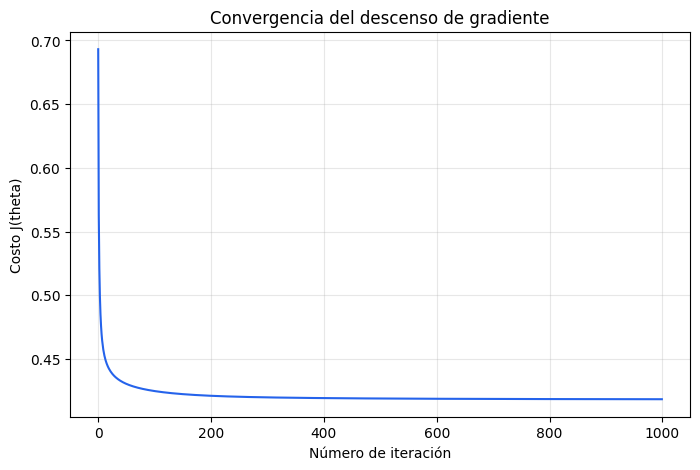

In [35]:
plt.figure(figsize=(8,5))
plt.plot(range(len(J_history)), J_history, color='#2563eb')
plt.xlabel('Número de iteración')
plt.ylabel('Costo J(theta)')
plt.title('Convergencia del descenso de gradiente')
plt.grid(alpha=0.3)
plt.show()

## 11. Predicción y evaluación del modelo

Se define una función `predict` que clasifica como 1 (cancelada) toda reserva cuya probabilidad estimada sea mayor o igual a 0.5, y como 0 en caso contrario. Luego se calcula la exactitud (accuracy) tanto en el conjunto de entrenamiento como en el de prueba. Que ambos valores sean parecidos entre sí es una señal de que el modelo generaliza bien y no está sobreajustado (overfitting) a los datos de entrenamiento.

In [36]:
def predict(theta, X, umbral=0.5):
    probabilidades = sigmoid(X.dot(theta))
    return (probabilidades >= umbral).astype(int)

pred_train = predict(theta_final, X_train_b)
pred_test = predict(theta_final, X_test_b)

exactitud_train = np.mean(pred_train == y_train)
exactitud_test = np.mean(pred_test == y_test)

print(f'Exactitud en entrenamiento: {exactitud_train*100:.2f}%')
print(f'Exactitud en prueba: {exactitud_test*100:.2f}%')

Exactitud en entrenamiento: 81.20%
Exactitud en prueba: 81.20%


### 11.1 Matriz de confusión y métricas adicionales

La exactitud por sí sola puede ser engañosa sobre todo porque el dataset no está perfectamente balanceado (63% de reservas no canceladas frente a 37% canceladas). Por eso se calcula también, de forma manual, la matriz de confusión y las métricas de precisión (precision), sensibilidad (recall) y F1 sobre el conjunto de **prueba**, que es el que realmente demuestra qué tan efectivo es el modelo con datos nunca vistos durante el entrenamiento.

- **Verdaderos positivos (VP):** reservas canceladas que el modelo predijo correctamente como canceladas.
- **Verdaderos negativos (VN):** reservas no canceladas que el modelo predijo correctamente como no canceladas.
- **Falsos positivos (FP):** reservas no canceladas que el modelo predijo (incorrectamente) como canceladas.
- **Falsos negativos (FN):** reservas canceladas que el modelo predijo (incorrectamente) como no canceladas.

In [37]:
VP = np.sum((pred_test == 1) & (y_test == 1))
VN = np.sum((pred_test == 0) & (y_test == 0))
FP = np.sum((pred_test == 1) & (y_test == 0))
FN = np.sum((pred_test == 0) & (y_test == 1))

matriz = np.array([[VN, FP], [FN, VP]])
print('Matriz de confusión (conjunto de prueba):')
print('               Predicho: No   Predicho: Si')
print(f'Real: No       {VN:>10}   {FP:>10}')
print(f'Real: Si       {FN:>10}   {VP:>10}')

precision = VP / (VP + FP)
recall = VP / (VP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print()
print(f'Precision (de las que predije como canceladas, cuantas lo eran de verdad): {precision:.4f}')
print(f'Recall (de las que realmente se cancelaron, cuantas detecte):              {recall:.4f}')
print(f'F1-score (balance entre precision y recall):                              {f1:.4f}')

Matriz de confusión (conjunto de prueba):
               Predicho: No   Predicho: Si
Real: No            13958         1075
Real: Si             3413         5431

Precision (de las que predije como canceladas, cuantas lo eran de verdad): 0.8348
Recall (de las que realmente se cancelaron, cuantas detecte):              0.6141
F1-score (balance entre precision y recall):                              0.7076


## 12. Predicciones sobre casos individuales

Para demostrar de forma concreta la efectividad del modelo, se toman 10 reservas al azar del conjunto de prueba (que el modelo nunca usó para entrenar) y se comparan sus predicciones contra el valor real.

In [38]:
indices_muestra = np.random.choice(X_test_b.shape[0], size=10, replace=False)

muestra = pd.DataFrame({
    'Prediccion': pred_test[indices_muestra],
    'Valor_real': y_test[indices_muestra].astype(int),
    'Correcta': (pred_test[indices_muestra] == y_test[indices_muestra].astype(int))
})
muestra

,Prediccion,Valor_real,Correcta
0,0,0,True
1,1,1,True
2,1,1,True
3,1,0,False
4,0,0,True
5,0,0,True
6,1,1,True
7,0,0,True
8,0,1,False
9,1,1,True


## 13. Conclusiones

- El modelo de regresión logística, entrenado desde cero con descenso de gradiente, alcanza una exactitud de aproximadamente 81% tanto en entrenamiento como en prueba, lo que indica que aprendió patrones generalizables del dataset y no memorizó los datos de entrenamiento.
- El paso de preprocesamiento con Pandas fue decisivo para el resultado: eliminar las columnas con fuga de información (`reservation_status`) fue especialmente importante, ya que de haberlas dejado el modelo hubiera alcanzado una exactitud artificialmente perfecta sin haber aprendido nada útil.
- El escalado de las propiedades numéricas permitió que el descenso de gradiente convergiera en un número razonable de iteraciones; sin este paso, propiedades con escalas muy distintas (como `lead_time` frente a `adults`) hubieran dificultado la convergencia.
